In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.style.use('ggplot')

In [3]:
def lorenz_system(t, state, sigma, r, b):
    """Правые части дифференциальных уравнений системы Лоренца."""
    x, y, z = state
    dx_dt = sigma * (y - x)
    dy_dt = r * x - y - x * z
    dz_dt = x * y - b * z
    return np.array([dx_dt, dy_dt, dz_dt])


def rk4_step(f, t, state, dt, *args):
    """Один шаг стандартного метода Рунге-Кутты 4-го порядка."""
    k1 = f(t, state, *args)
    k2 = f(t + dt / 2, state + dt / 2 * k1, *args)
    k3 = f(t + dt / 2, state + dt / 2 * k2, *args)
    k4 = f(t + dt, state + dt * k3, *args)
    return state + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)


def simulate_lorenz(sigma, r, b, state0, t_max, dt):
    """Численное интегрирование системы Лоренца."""
    steps = int(t_max / dt)
    t_values = np.linspace(0, t_max, steps)
    states = np.zeros((steps, 3))
    states[0] = state0
    for i in range(1, steps):
        states[i] = rk4_step(lorenz_system, t_values[i - 1], states[i - 1], dt, sigma, r, b)
    return t_values, states


sigma_base = 10.0
b_base = 8.0 / 3.0

Б) Классический аттрактор (r = 28)

б)


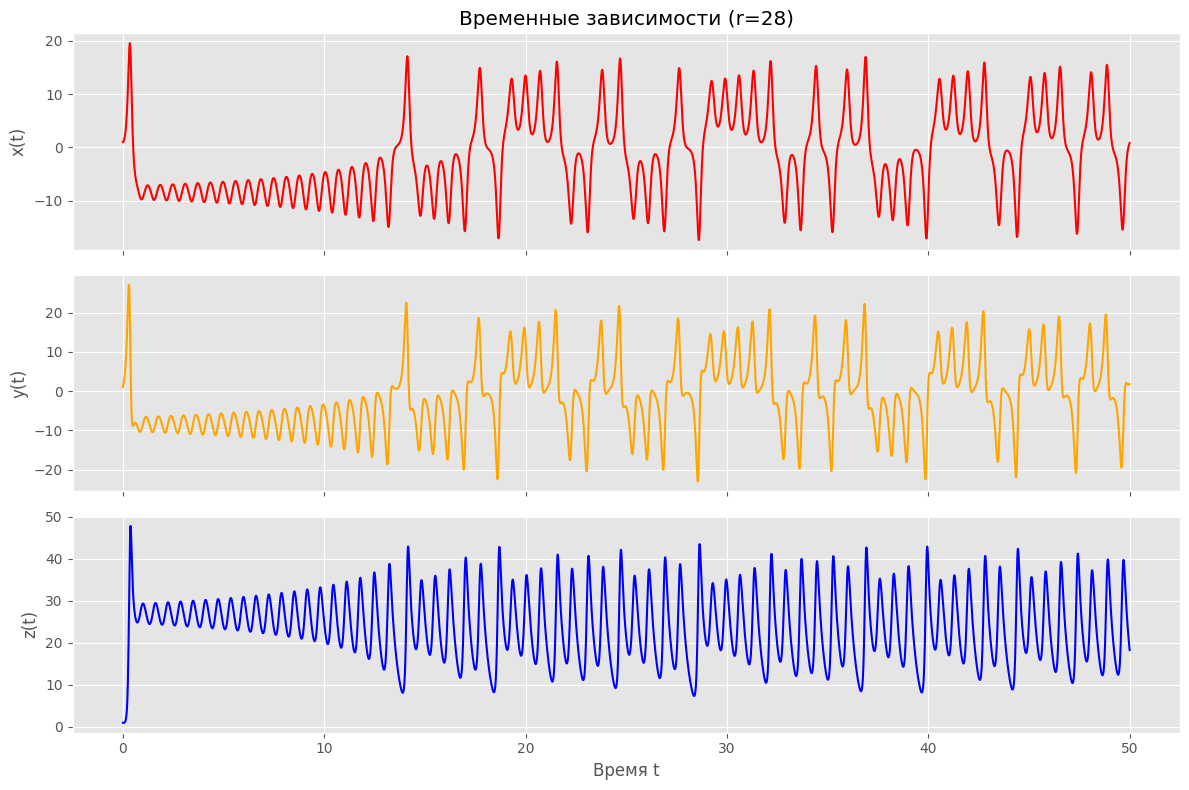

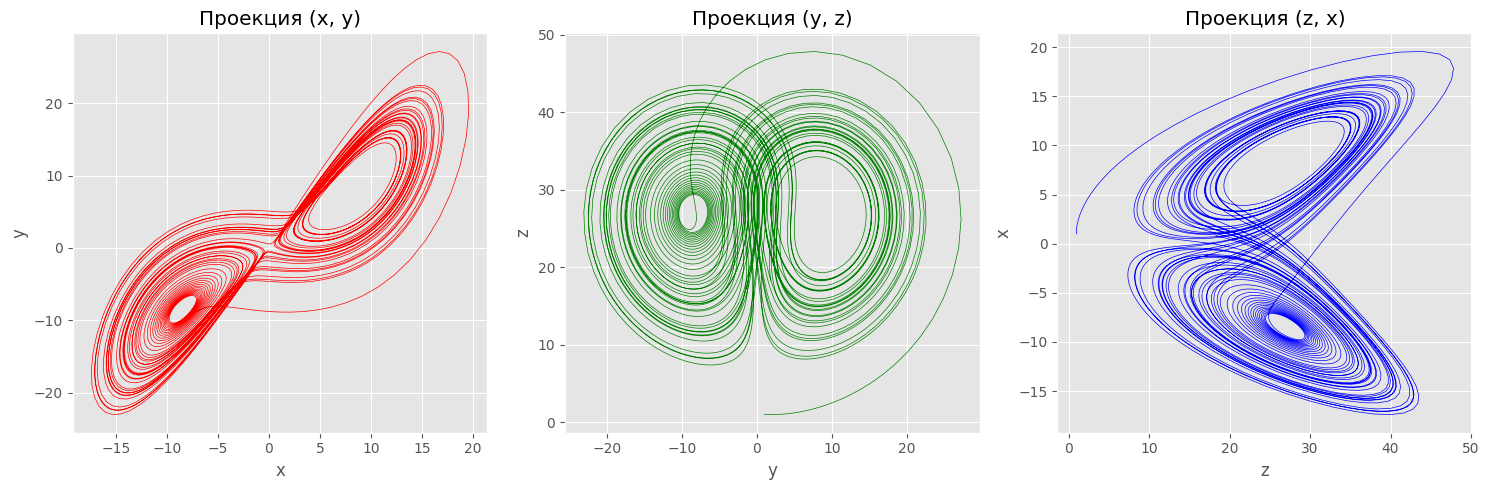

In [13]:
print("б)")
r_b = 28.0
state0_b = [1.0, 1.0, 1.0]  # Начальное условие
t_max_b = 50.0
dt_b = 0.01

t_b, states_b = simulate_lorenz(sigma_base, r_b, b_base, state0_b, t_max_b, dt_b)
x_b, y_b, z_b = states_b[:, 0], states_b[:, 1], states_b[:, 2]

# Графики временной зависимости
fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axs[0].plot(t_b, x_b, color='red');
axs[0].set_ylabel('x(t)');
axs[0].set_title('Временные зависимости (r=28)')
axs[1].plot(t_b, y_b, color='orange');
axs[1].set_ylabel('y(t)')
axs[2].plot(t_b, z_b, color='blue');
axs[2].set_ylabel('z(t)');
axs[2].set_xlabel('Время t')
plt.tight_layout()
plt.show()

# Фазовые портреты (проекции)
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].plot(x_b, y_b, lw=0.5, color='red');
axs[0].set_xlabel('x');
axs[0].set_ylabel('y');
axs[0].set_title('Проекция (x, y)')
axs[1].plot(y_b, z_b, lw=0.5, color='green');
axs[1].set_xlabel('y');
axs[1].set_ylabel('z');
axs[1].set_title('Проекция (y, z)')
axs[2].plot(z_b, x_b, lw=0.5, color='blue');
axs[2].set_xlabel('z');
axs[2].set_ylabel('x');
axs[2].set_title('Проекция (z, x)')
plt.tight_layout()
plt.show()

В) Поведение траектории при разных r

в)


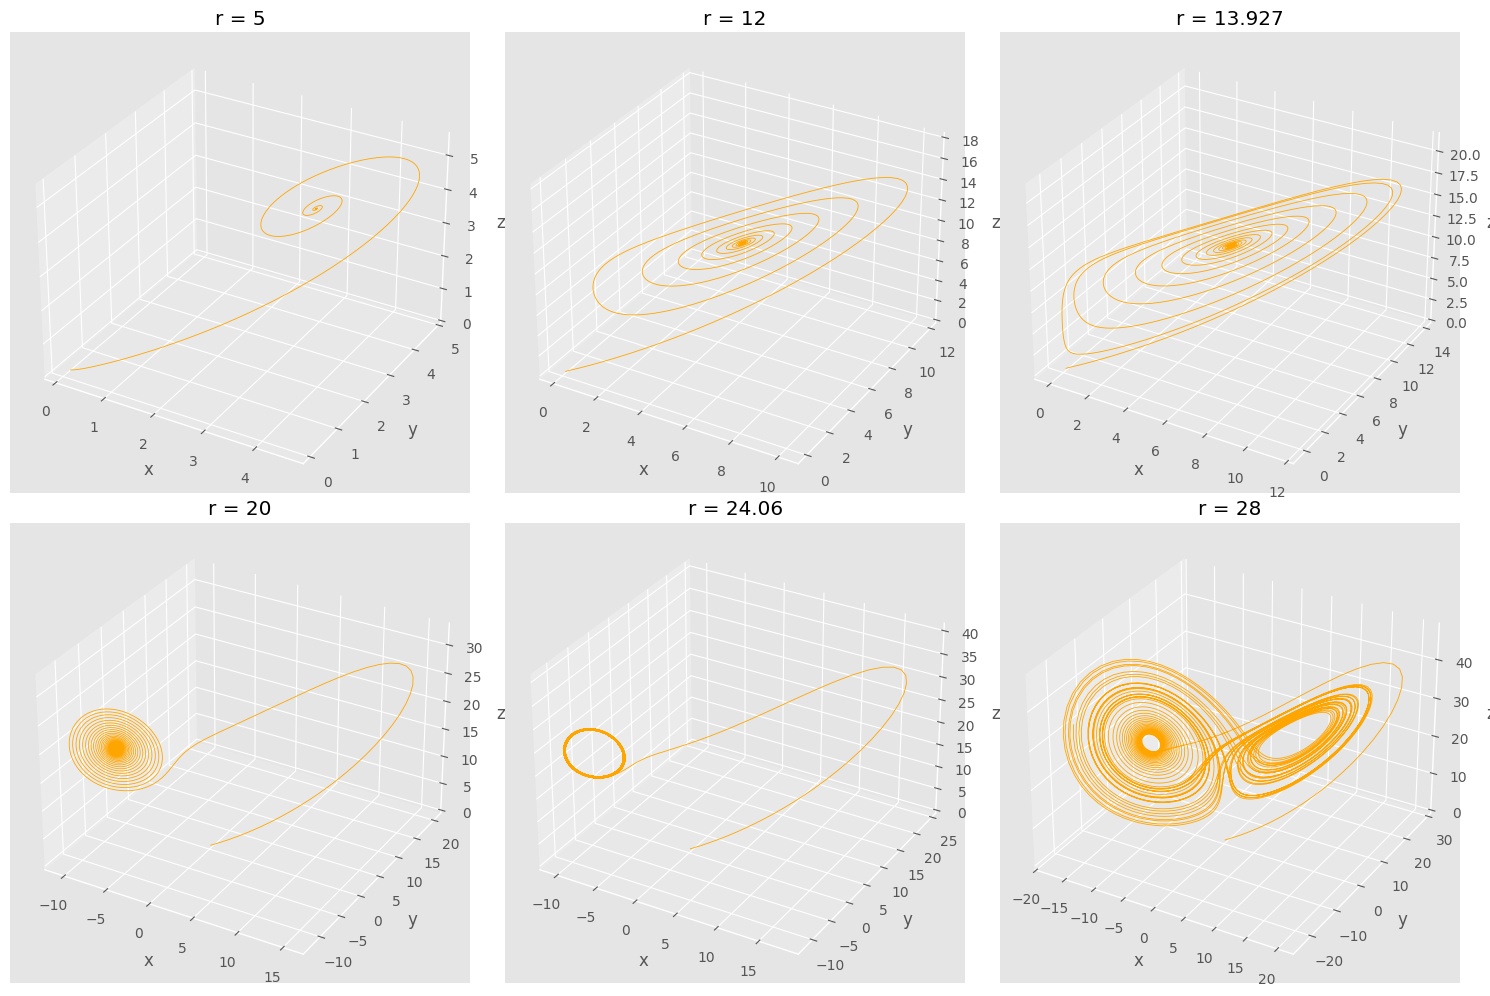

In [5]:
print("в)")
r_values = [5, 12, 13.927, 20, 24.06, 28]
state0_c = [0.1, 0.1, 0.1]
t_max_c = 50.0
dt_c = 0.01

fig = plt.figure(figsize=(15, 10))
for i, r_val in enumerate(r_values):
    t_c, states_c = simulate_lorenz(sigma_base, r_val, b_base, state0_c, t_max_c, dt_c)
    ax = fig.add_subplot(2, 3, i + 1, projection='3d')
    ax.plot(states_c[:, 0], states_c[:, 1], states_c[:, 2], lw=0.6, color='orange')
    ax.set_title(f'r = {r_val}')
    ax.set_xlabel('x');
    ax.set_ylabel('y');
    ax.set_zlabel('z')
plt.tight_layout()
plt.show()

Г) Бифуркационное дерево (переход к хаосу через удвоение периода)

г)


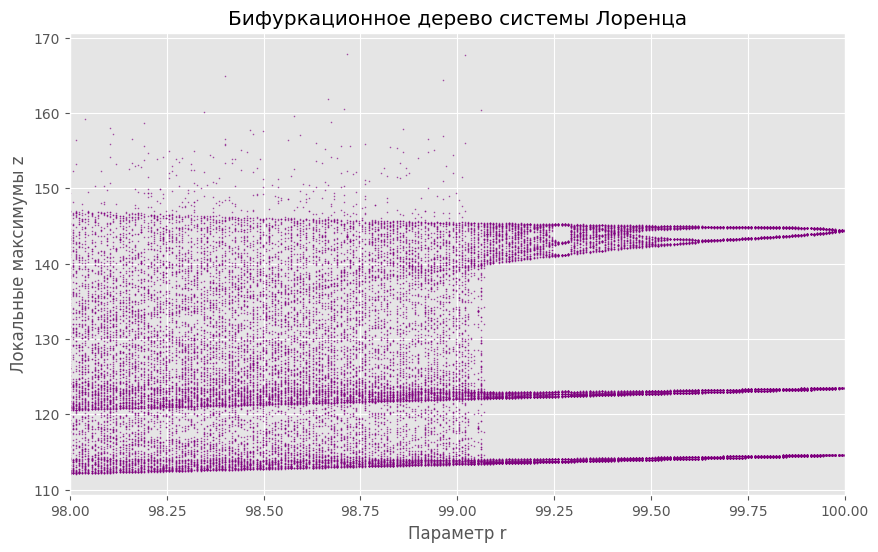

In [14]:
print("г)")
# Диапазон r: от 98 до 100
r_range = np.linspace(98, 100, 250)
t_transient = 40.0
t_eval = 60.0
t_max_d = t_transient + t_eval
dt_d = 0.005
r_plot = []
z_peaks_plot = []
state_d = [1.0, 1.0, 1.0]

for r_val in r_range:
    # Интегрируем для каждого r
    t_d, states_d = simulate_lorenz(sigma_base, r_val, b_base, state_d, t_max_d, dt_d)
    # Отбрасываем переходной процесс
    transient_steps = int(t_transient / dt_d)
    z_eval = states_d[transient_steps:, 2]
    # Находим локальные максимумы переменной z
    peaks_indices, _ = find_peaks(z_eval)
    peaks_z = z_eval[peaks_indices]
    r_plot.extend([r_val] * len(peaks_z))
    z_peaks_plot.extend(peaks_z)
    # Используем последнее состояние как начальное для следующего r (ускоряет сходимость)
    state_d = states_d[-1]

# Построение бифуркационного дерева
plt.figure(figsize=(10, 6))
plt.scatter(r_plot, z_peaks_plot, s=0.5, color='purple', alpha=0.5)
plt.title('Бифуркационное дерево системы Лоренца')
plt.xlabel('Параметр r')
plt.ylabel('Локальные максимумы z')
plt.grid(True)
plt.xlim(98, 100)
plt.show()